# Gaussian Processes

## In a Nutshell

Gaussian Processes (GPs) are tools for **learning functions** from data and returning **uncertainty-aware predictions**. They can:

- fit **non-linear** relationships
- make predictions for **new inputs**
- provide **sensible uncertainties** (wider where we have less data)
- **adapt model complexity** as more observations arrive (non-parametric behaviour)

## Paradigm

The *GP paradigm* frames three questions:
- Which functions are probable **before** seeing data? → **GP Prior**
- How do function values **correlate** across inputs? → **GP Kernel**
- Which functions are probable **after** seeing data? → **GP Posterior**.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (4, 4)

In [3]:
def make_sigma(a: float, b: float, rho: float):
    a = max(a, 1e-6)
    b = max(b, 1e-6)
    # enforce |rho| < sqrt(a*b)
    bound = np.sqrt(a*b) - 1e-6
    rho_safe = float(np.clip(rho, -bound, bound))
    Sigma = np.array([[a, rho_safe],
                      [rho_safe, b]], dtype=float)
    clipped = (rho_safe != rho)
    return Sigma, clipped, bound

In [4]:
def gaussian_pdf_2d(X, Y, mean, Sigma):
    pos = np.dstack((X, Y))
    diff = pos - mean
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    expo = np.einsum('...i,ij,...j', diff, inv, diff)
    return norm * np.exp(-0.5 * expo)

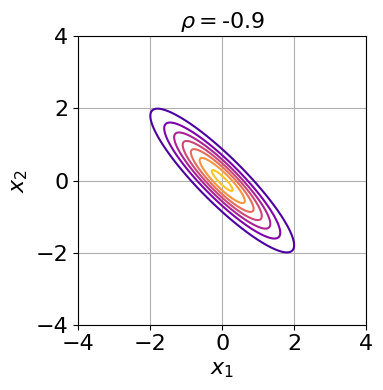

In [5]:
a=1.0
b=1.0
rho=-0.9

mean = np.array([0.0, 0.0])
Sigma, clipped, bound = make_sigma(a, b, rho)
a_, b_, r_ = Sigma[0,0], Sigma[1,1], Sigma[0,1]

grid = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(grid, grid)
Z = gaussian_pdf_2d(X, Y, mean, Sigma)

plt.figure()
cs = plt.contour(X, Y, Z, levels=7, cmap='plasma')
plt.gca().set_aspect('equal')
plt.grid()

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks(np.arange(-4, 5, step=2), fontsize=16)
plt.yticks(np.arange(-4, 5, step=2), fontsize=16)
plt.xlabel(r"$x_1$", fontsize=16)
plt.ylabel(r"$x_2$", fontsize=16)
plt.title(
    # f"a={a_:0.1f}, b={b_:0.1f}"
    # ", "
    r"$\rho=$" f"{r_:0.1f}"
    , fontsize=16)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
plt.rcParams["figure.figsize"] = (6, 6)

In [7]:
def make_sigma(a: float, b: float, rho: float):
    a = max(a, 1e-8)
    b = max(b, 1e-8)
    bound = np.sqrt(a*b) - 1e-9
    rho_safe = float(np.clip(rho, -bound, bound))
    Sigma = np.array([[a, rho_safe],
                      [rho_safe, b]], dtype=float)
    clipped = (rho_safe != rho)
    return Sigma, clipped, bound

def pdf_2d_gaussian(X, Y, mean, Sigma):
    pos = np.dstack((X, Y))
    diff = pos - mean
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    expo = np.einsum('...i,ij,...j', diff, inv, diff)
    return norm * np.exp(-0.5 * expo)

def pdf_1d(x, mu, var):
    var = max(var, 1e-12)
    return (1.0/np.sqrt(2*np.pi*var)) * np.exp(-0.5*((x-mu)**2)/var)

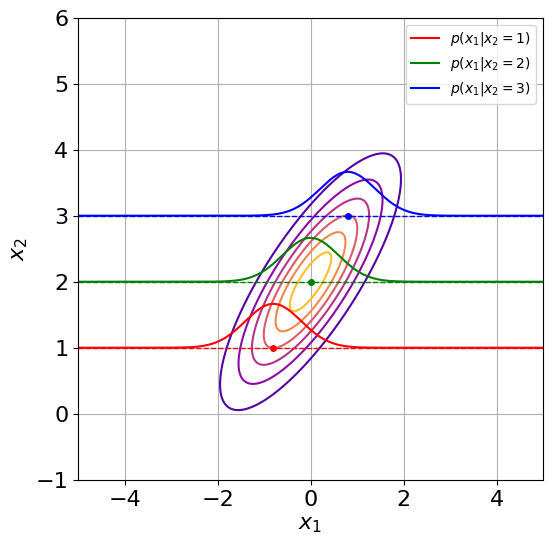

In [8]:
x2_obs_1=1.0
x2_obs_2=2.0
x2_obs_3=3.0
color = 'red'
a=1.0
b=1.0
rho=0.8
mu1 = 0.0
mu2 = 2.0
Sigma, clipped, bound = make_sigma(a, b, rho)
rho_eff = Sigma[0,1]
mean = np.array([mu1, mu2])
x = np.linspace(-5, 5, 300)
y = np.linspace(-1.0, 6, 300)
X, Y = np.meshgrid(x, y)
Z = pdf_2d_gaussian(X, Y, mean, Sigma)

# plot 1
plt.figure()
plt.grid()
plt.contour(X, Y, Z, levels=7, cmap='plasma')
plt.xlim(-5, 5)
plt.ylim(-1.0, 6)
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$x_2$", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# plot 2
mean_cond = mu1 + (rho_eff/b) * (x2_obs_1 - mu2)
var_cond = a - (rho_eff**2)/b
pdf_cond = pdf_1d(x, mean_cond, var_cond)
y_curve = x2_obs_1 + pdf_cond
plt.plot(x, y_curve, 'red', label='$p(x_1|x_2=1)$')
plt.plot([mean_cond], [x2_obs_1], 'red', marker='o', markersize=4)
plt.plot(x, np.ones_like(x)*x2_obs_1, '--', color='red', linewidth=1)

# plot 3
mean_cond = mu1 + (rho_eff/b) * (x2_obs_2 - mu2)
var_cond = a - (rho_eff**2)/b
pdf_cond = pdf_1d(x, mean_cond, var_cond)
y_curve = x2_obs_2 + pdf_cond
plt.plot(x, y_curve, 'green', label='$p(x_1|x_2=2)$')
plt.plot([mean_cond], [x2_obs_2], 'green', marker='o', markersize=4)
plt.plot(x, np.ones_like(x)*x2_obs_2, '--', color='green', linewidth=1)

# plot 4
mean_cond = mu1 + (rho_eff/b) * (x2_obs_3 - mu2)
var_cond = a - (rho_eff**2)/b
pdf_cond = pdf_1d(x, mean_cond, var_cond)
y_curve = x2_obs_3 + pdf_cond
plt.plot(x, y_curve, 'blue', label='$p(x_1|x_2=3)$')
plt.plot([mean_cond], [x2_obs_3], 'blue', marker='o', markersize=4)
plt.plot(x, np.ones_like(x)*x2_obs_3, '--', color='blue', linewidth=1)

plt.legend()
plt.show()

# Linear regression, Gaussian distributions, and Gaussian Processes

## Learning objectives

This notebook is designed to introduce you to the multivariate Gaussian distribution and the fundamentals of Bayesian Lineare Regression. After working through it, you should be able to:

- Manipulate, implement, and draw samples from multivariate Gaussian distributions.

- Describe the roles of the prior, likelihood, posterior, and model evidence in Bayesian Linear Regression.

- Compute, visualize, and interpret the posterior distribution of the regression weights in a linear regression model.

The notebook relies solely on the `numpy` module. Before starting, review the first two sections of the lecture slides, and then proceed with the material presented here.

In [9]:
%matplotlib inline

import numpy as np
import pylab as plt
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

## Gaussian linear regression

Linear regression is perhaps the most frequently used technique in applied statistics for modelling the relationship between set of a predictor variables $\left\lbrace \mathbf{x}_i \right\rbrace_{i=1}^N$ and a response variable $\left\lbrace y_i \right\rbrace_{i=1}^N$. More formally, let $\mathbf{X} \in \mathbb{R}^{N \times D}$ be a design matrix and let  $\mathbf{y} \in \mathbb{R}^N$ be the response variables collected into a single vector, then the linear regression model is given by

\begin{align}
\mathbf{y} = \mathbf{X}\mathbf{w} + \mathbf{\epsilon},
\end{align}

where $\mathbf{w} \in \mathbb{R}^D$ is the regression weights and $\mathbf{\epsilon} \in \mathbb{R}^N$ is the observation noise vector.

Assuming isotropic Gaussian noise and imposing a multivariate Gaussian prior on $\mathbf{w} \sim \mathcal{N}\left(\mathbf{m}, \mathbf{S}\right)$ gives rise to the following joint distribution

\begin{align}
p(\mathbf{y}, \mathbf{w}) = p\left(\mathbf{y}|\mathbf{w}\right)p\left(\mathbf{w}\right) = \mathcal{N}\left(\mathbf{y}\big|\mathbf{Xw}, \sigma^2\mathbf{I}\right)\mathcal{N}\left(\mathbf{w}\big|\mathbf{m}, \mathbf{S}\right).
\end{align}

In this notebook, we will use the following simple model as running example:

\begin{align}
y_i = ax_i + b +  \epsilon_i = \begin{bmatrix}x_i&1\end{bmatrix}\begin{bmatrix}a\\b\end{bmatrix} + \epsilon_i
\end{align}

That is, the parameters are $\mathbf{w} = \left[a, b\right]$, where $a$ and $b$ are the slope and intercept of the line, respectively. Furthermore, we will assume $\mathbf{m} = \mathbf{0}$, $\mathbf{S} = \mathbf{I}$, and $\sigma^2 = 2$.

We will use the following dataset with $N = 8$ data points

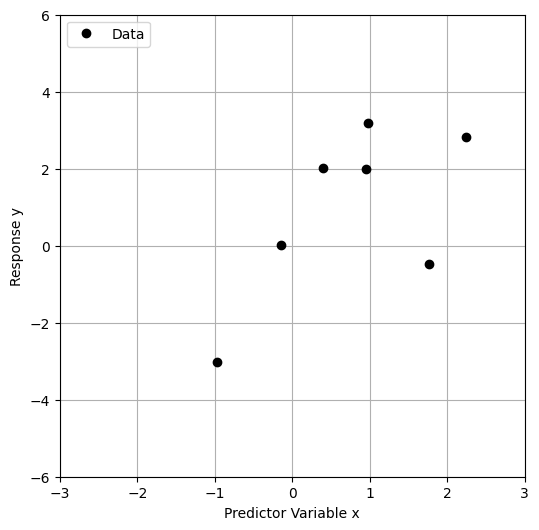

In [10]:
# hyperparameters of the prior
m = np.zeros((2, 1))
S = 1.0*np.identity(2)

# noise variance
sigma2 = 2

# data
N = 8
x = np.array([1.764, 0.4, 0.979, 2.241, 1.868, -0.977,  0.95, -0.151])[:, None]
y = np.array([-0.464, 2.024, 3.191, 2.812, 6.512, -3.022, 1.99, 0.009])[:, None]

# plot
plt.plot(x, y, 'k.', label='Data', markersize=12)
plt.xlabel('Predictor Variable x')
plt.ylabel('Response y')
plt.legend()
plt.xlim((-3, 3))
plt.ylim((-6, 6))
plt.grid()

## The prior, likelihood and posterior

This section illustrates the basic building blocks of the linear model.

Reference: Rasmussen and Williams, Section 2.1, for the derivation of these functions (http://www.gaussianprocess.org/gpml/
).

### The multivariate Gaussian density function
The multivariate Gaussian density function, implemented using `Numpy`.

\begin{align}
N(x | \mu, \Sigma ) = (2\pi)^{-\frac{D}{2}} | \Sigma |^{-\frac{1}{2}} \exp\left[-\frac{1}{2}(x - \mu)^T \Sigma^{-1} (x - \mu) \right]
\end{align}



In [11]:
def mvn_pdf(x, mu, Sigma, log=True):
    """ Returns the density of a multivariate Gaussian distribution
    with mean mu and covariance Sigma at point x

    Arguments:
    x     -- (Dx1) evaluation point
    mu    -- (Dx1) mean vector
    Sigma -- (DxD) covariance matrix
    log   -- (bool) if true, return log density. If false, return the density. (default=True)

    Returns:
    (scalar) density
    """
    D = len(mu)
    Sigma = Sigma + 1e-10 * np.identity(D)
    L = np.linalg.cholesky(Sigma)
    v = np.linalg.solve(L, x-mu)
    const_term = -0.5 * D * np.log(2 * np.pi)
    det_term = -0.5 * 2 * np.sum(np.log(np.diag(L)))
    quad_term = -0.5 * np.sum(v **2)
    if log:
        return const_term + det_term + quad_term
    else:
        return np.exp(const_term + det_term + quad_term)

- Computes the (log-)density of a multivariate Gaussian  
  $\mathcal{N}(x \mid \mu, \Sigma)$ using a numerically stable Cholesky decomposition of the covariance matrix.
- Adds a small diagonal jitter to $\Sigma$ to ensure positive definiteness and avoid numerical issues during factorization.
- Uses the Cholesky factor $L$ to efficiently solve  
  $v = L^{-1}(x - \mu)$, which is required to compute the quadratic form  
  $(x - \mu)^\top \Sigma^{-1} (x - \mu) = \|v\|^2$.
- Combines the constant term, log-determinant term (computed from $\log \det \Sigma = 2 \sum \log L_{ii}$), and quadratic term to return either the log-density or the density.








In [12]:
from scipy.stats import multivariate_normal

x_test = np.array([1,1])
print("Scipy multivariate_normal model")
pdf = multivariate_normal.pdf(x_test, mean=m.flatten(), cov=S)
print("The pdf of [1,1] is", pdf)
logpdf = multivariate_normal.logpdf(x_test, mean=m.flatten(), cov=S)
print("The logpdf of [1,1] is", logpdf)

x_test = np.array([1,1]).reshape(2,1)
print("\nOwn mvn_pdf")
pdf = mvn_pdf(x_test, mu=m, Sigma=S, log=False)
print("The pdf of [1,1] is", pdf)
logpdf = mvn_pdf(x_test, mu=m, Sigma=S, log=True)
print("The logpdf of [1,1] is", logpdf)

Scipy multivariate_normal model
The pdf of [1,1] is 0.05854983152431917
The logpdf of [1,1] is -2.8378770664093453

Own mvn_pdf
The pdf of [1,1] is 0.05854983152431917
The logpdf of [1,1] is -2.8378770664093453


### The Log density functions
The Log density of the (i) prior, (ii) likelihood, and (iii) posterior (likelihood times prior), implemented using the <tt>mvn_pdf</tt> function.

In [13]:
def predict(x, a, b):
    """ returns prediction for inputs x given parameter (a,b)

    Arguments:
    x    --  (Nx1) vector of inputs
    a    --  slope parameter
    b    --  intercept parameter

    Returns:
    (Nx1) vector of predictions
    """
    return a*x + b


def log_prior(a, b, m, S):
    """ returns the log density of the prior at the points (a,b) given m and S

    Arguments:
    a    -- (scalar) slope parameter
    b    -- (scalar) intercept parameter
    m    -- (2x1) The prior mean
    S    -- (2x2) The prior covariance

    Returns
    (scalar) log density for the pair (a,b)

    """
    return mvn_pdf(np.array([a,b])[:, None], m, S, log=True)

def log_likelihood(x, y, a, b):
    """ returns the log-likelihood for the data (x,y) given the parameters (a,b)

    Arguments:
    x    -- (Nx1) vector of inputs
    y    -- (Nx1) vector of responses
    a    -- slope parameter
    b    -- intercept parameter

    Returns:
    (scalar) log likelihood of (x,y)
    """
    return np.sum(log_npdf(y, predict(x,a,b), sigma2))

log_npdf = lambda x, m, v: -0.5 * np.log(2* np.pi * v) - 0.5 * (x - m)**2/v

def log_posterior(x, y, a, b, m, S):
    """ returns the log posterior at (a,b), given the data (x,y) and the prior parameters (m, S)

    Arguments:
    x    -- (Nx1) vector of inputs
    y    -- (Nx1) vector of responses
    a    -- slope parameter
    b    -- intercept parameter
    m    -- (2x1) The prior mean
    S    -- (2x2) The prior covariance

    Returns:
    (scalar) log posterior of (x,y)
    """

    log_posterior = log_prior(a,b,m,S) + log_likelihood(x,y,a,b)
    return log_posterior

### The Visualization
Visualization of the prior density, the likelihood and the posterior as a function of $a$ and $b$.



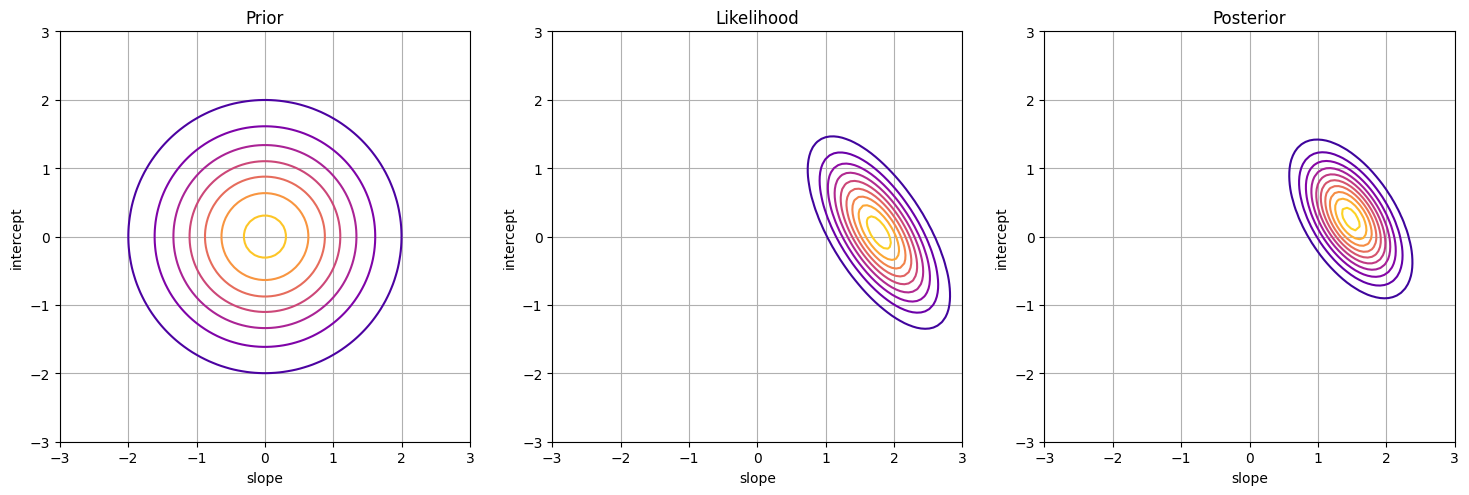

In [14]:
a_array = np.linspace(-3,3,100)
b_array = np.linspace(-3,3,100)

def log_to_density(Z):
    Z = Z - np.max(Z)
    Z = np.exp(Z)
    return Z/np.sum(Z)

def plot_prior_density(m, S):

    A_array, B_array = np.meshgrid(a_array, b_array)
    Z = np.array([log_prior(ai, bi, m, S) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
    Z = Z.reshape((len(a_array), len(b_array)))
    plt.contour(a_array, b_array, log_to_density(Z), cmap='plasma')
    plt.xlabel('slope')
    plt.ylabel('intercept')
    plt.gca().set_aspect('equal', adjustable='box')


def plot_likelihood(x, y):

    A_array, B_array = np.meshgrid(a_array, b_array)
    Z = np.array([log_likelihood(x, y, ai, bi) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
    Z = Z.reshape((len(a_array), len(b_array)))
    plt.contour(a_array, b_array, log_to_density(Z), 10, cmap='plasma')
    plt.xlabel('slope')
    plt.ylabel('intercept')
    plt.gca().set_aspect('equal', adjustable='box')


def plot_posterior_density(x, y, m, S):

    A_array, B_array = np.meshgrid(a_array, b_array)
    Z = np.array([log_posterior(x, y, ai, bi, m, S) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
    Z = Z.reshape((len(a_array), len(b_array)))
    plt.contour(a_array, b_array, log_to_density(Z), 10, cmap='plasma')
    plt.xlabel('slope')
    plt.ylabel('intercept');
    plt.gca().set_aspect('equal', adjustable='box')


# plot
plt.figure(figsize=(18,6))
plt.subplot(1, 3, 1)
plot_prior_density(m, S)
plt.title('Prior')
plt.grid()

plt.subplot(1, 3, 2)
plot_likelihood(x, y)
plt.title('Likelihood')
plt.grid()

plt.subplot(1, 3, 3)
plot_posterior_density(x, y, m, S)
plt.title('Posterior')
plt.grid()

## Analytical expression of the posterior distribution


Derivation of the posterior $p(\mathbf{w}\big|\mathbf{y}) = \mathcal{N}\left(\mathbf{w}\big|\mu, \Sigma\right)$ yields:


\begin{align}
\Sigma &= \left(\frac{1}{\sigma^2}\mathbf{X}^T\mathbf{X} + \mathbf{S}^{-1}\right)^{-1}\\
\mu &= \Sigma\left(\frac{1}{\sigma^2}\mathbf{X}^T\mathbf{y} + \mathbf{S}^{-1}\mathbf{m}\right)
\end{align}


Reference: Rasmussen and Williams, Section 2.1.1, for the derivation of these functions (http://www.gaussianprocess.org/gpml/
).


### The Implementation
Implementation of the function for computing the analytical posterior distribution.

In [15]:
def design_matrix(x):
    """ returns the design matrix for a vector of input values x

    Arguments:
    x    -- (Nx1) vector of inputs

    Returns:
    (Nx2) design matrix

    """
    X = np.column_stack((x, np.ones(len(x))))
    return X

def compute_posterior(x, y, m, S, sigma2):
    """ return the posterior mean and covariance of w given (x,y)
    and hyperparameters m, S and sigma2

    Arguments:
    x      -- (Nx1) vector of inputs
    y      -- (Nx1) vector of responses
    m      -- (Dx1) prior mean
    S      -- (DxD) prior covariance
    sigma2 -- (scalar) noise variance

    Returns:
    mu     -- (Dx1) posterior mean
    Sigma  -- (DxD) posterior covariance

    """
    import scipy as sc
    Sinv = np.linalg.inv(S)
    X = design_matrix(x)
    Sigmainv = Sinv + np.dot(X.T, X)/sigma2
    L = sc.linalg.cho_factor(Sigmainv)
    scaled_mu = np.dot(X.T, y)/sigma2 + np.linalg.solve(S,m)
    mu = sc.linalg.cho_solve(L, scaled_mu)
    Sigma = sc.linalg.cho_solve(L, np.identity(len(m)))

    return mu, Sigma

- Computes the inverse of the posterior covariance matrix  
  $\Sigma_{\text{post}}^{-1} = S^{-1} + \frac{1}{\sigma^2} X^\top X$
  using the inverse of the prior covariance `Sinv = np.linalg.inv(S)` and the design matrix `X = design_matrix(x)`.

- Forms the Cholesky factorization of the inverse of the inverse posterior covariance matrix using  
  `sc.linalg.cho_factor(Sigmainv)`, enabling stable and efficient solutions for both the posterior mean and covariance without explicitly inverting matrices.

- Computes the scaled right-hand side  
  $\frac{1}{\sigma^2} X^\top y + S^{-1} m$  
  using `np.dot(X.T, y)/sigma2 + np.linalg.solve(S, m)`; the call to `np.linalg.solve` computes $S^{-1}m$ more accurately than explicitly forming $S^{-1}$.

- Solves the linear system  
  $\Sigma_{\text{post}}^{-1}\,\mu_{\text{post}} = \frac{1}{\sigma^2}X^\top y + S^{-1} m$
  via `sc.linalg.cho_solve(L, scaled_mu)`, yielding the posterior mean vector `mu`.

- Computes the posterior covariance matrix  
  $\Sigma_{\text{post}} = (\Sigma_{\text{post}}^{-1})^{-1}$
  by solving `cho_solve(L, I)` where `I = np.identity(len(m))`; this avoids explicit matrix inversion and ensures numerical stability.



### The Application
The posterior mean and covariance for the data set  $(\mathbf{x}, \mathbf{y})$ are calculated using the function above. The plot of the resulting density matches with the posterior distribution from section 1.3.3.


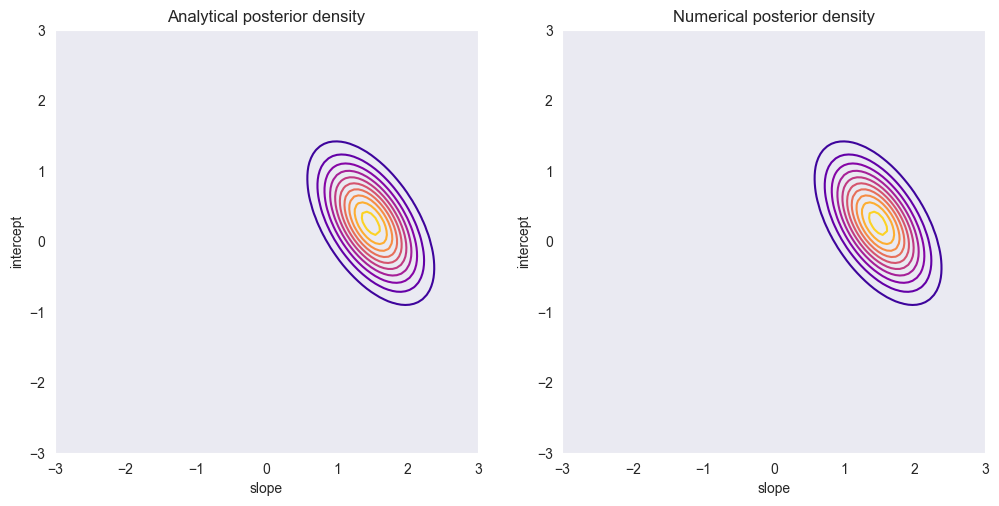

In [16]:
mu, Sigma = compute_posterior(x, y, m, S, sigma2)

A_array, B_array = np.meshgrid(a_array, b_array)
AB = np.column_stack((A_array.ravel(), B_array.ravel()))
from scipy.stats import multivariate_normal as mvn
vals = np.array([mvn.logpdf(ab, mu.ravel(), Sigma) for ab in AB]).reshape((len(a_array), len(b_array)))

# plot
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.contour(a_array, b_array, log_to_density(vals), 10, cmap='plasma')
plt.title('Analytical posterior density')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()

plt.subplot(1, 2, 2)
plot_posterior_density(x,y,m,S)
plt.title('Numerical posterior density')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()

## Combining all of the above

All the functions implemented above are used to compute the posterior distribution $p\left(\mathbf{w}|\mathbf{y}\right)$ for various sizes of $N$. The cell below analyses the data set using $N$ data points, where the columns visualise (i) data and sample functions, (ii) the prior, (iii) the likelihood and (iv) posterior.

In [17]:
def generate_mvn_samples(mu, Sigma, M):
    """ return samples from a multivariate normal distribution N(mu, Sigma)

    Arguments:
    mu      -- (Dx1) mean vector
    Sigma   -- (DxD) covariance matrix
    M       -- (scalar) number of samples

    Returns:
    (DxM) matrix, where each column corresponds to a sample
    """

    jitter = 1e-8
    D = len(mu)
    L = np.linalg.cholesky(Sigma + jitter*np.identity(D))
    zs = np.random.normal(0, 1, size=(D, M))
    fs = mu + np.dot(L, zs)
    return fs

def compute_f_posterior(x, mu, Sigma):
    """ compute the posterior distribution of f(x) wrt. posterior distribution N(mu, Sigma)

    Arguments:
    x      -- (Nx1) vector of inputs
    mu     -- (2x1) mean vector
    Sigma  -- (2x2) covariance matrix

    Returns:
    mu_f   -- (Nx1) vector of pointwise posterior means at x
    var_f  -- (Nx1) vector of pointwise posterior variances at x

    """

    X = np.column_stack((x, np.ones(len(x))))
    mu_f = np.dot(X, mu)
    var_f = np.diag(np.dot(np.dot(X, Sigma), X.T))[:, None]

    return mu_f, var_f

- `generate_mvn_samples` samples from a multivariate normal $ \mathcal{N}(\mu, \Sigma)$ by computing a Cholesky factor `L = np.linalg.cholesky(Sigma + jitter*np.identity(D))`, where a small `jitter` term ensures that $\Sigma$ is numerically positive definite.
- Standard normal samples `zs` are drawn with `np.random.normal(0, 1, size=(D, M))`, giving a $D \times M$ matrix of i.i.d. $ \mathcal{N}(0, 1) $ variables; multiplying by `L` linearly transforms them to have covariance $\Sigma$.
- The final samples are constructed as `fs = mu + np.dot(L, zs)`, implementing $ f = \mu + L z $; this uses NumPy broadcasting to add the \(D\)-dimensional mean vector `mu` to each of the \(M\) sample columns.

- In `compute_f_posterior`, the design matrix `X = np.column_stack((x, np.ones(len(x))))` encodes a linear model $ f(x) = w_1 x + w_0 $, with the first column for the input $x$ and the second column for the intercept term.
- Given a posterior over weights $ w \sim \mathcal{N}(\mu, \Sigma) $, the induced posterior over function values is $ f(x) \sim \mathcal{N}(X\mu,\; X \Sigma X^\top) $; this is implemented by `mu_f = np.dot(X, mu)` for the mean.
- The pointwise posterior variances $\mathrm{Var}[f(x_i)]$ are the diagonal elements of $X \Sigma X^\top$; these are extracted via `np.diag(np.dot(np.dot(X, Sigma), X.T))[:, None]`, with `[:, None]` reshaping the vector into an $(N \times 1)$ column.


In [18]:
# New data set with more data points
np.random.seed(21340)
N_2 = 20
x_2 = np.array([1.764, 0.4, 0.979, 2.241, 1.868, -0.977,  0.95, -0.151, -0.103, 0.411, 0.144, 1.454, 0.761, 0.122,
              0.444, 0.334, 1.494, -0.205,  0.313, -0.854])[:, None]
y_2 = np.array([-0.464, 2.024, 3.191, 2.812, 6.512, -3.022, 1.99, 0.009, 2.513, 3.194, 0.935, 3.216, 0.386, -2.118,
               0.674, 1.222, 4.481, 1.893, 0.422, -1.209])[:, None]
xp = np.linspace(-3, 3, 50)[:, None]

def plot_BLR(n=2):
    # compute posterior & generate samples
    mu, Sigma = compute_posterior(x_2[:n, :], y_2[:n, :], m, S, sigma2)
    ahat, bhat = generate_mvn_samples(mu, Sigma, M=30)

    # plot
    plt.figure(figsize=(20, 10))

    plt.subplot2grid((1, 4), (0, 0))
    plt.plot(x_2[:n, :], y_2[:n, :], 'k.', markersize=12)
    plt.ylabel('N = %d' % n, fontweight='bold')
    for (ai, bi) in zip(ahat, bhat):
        plt.plot(xp, predict(xp, ai, bi), 'b-', alpha=0.25)
    mu_f, var_f = compute_f_posterior(xp, mu, Sigma)
    std_f = np.sqrt(var_f)
    plt.plot(xp, mu_f, 'r')
    plt.plot(xp, mu_f + 2*std_f, 'r--')
    plt.plot(xp, mu_f - 2*std_f, 'r--')
    plt.ylim((-6, 6))
    plt.title('Data points', fontweight='bold')
    plt.gca().set_box_aspect(1)
    plt.grid()

    plt.subplot2grid((1, 4), (0, 1))
    plot_prior_density(m, S)
    plt.title('Prior', fontweight='bold')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid()

    plt.subplot2grid((1, 4), (0, 2))
    plot_likelihood(x_2[:n, :], y_2[:n, :])
    plt.title('Likelihood', fontweight='bold')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid()

    plt.subplot2grid((1, 4), (0, 3))
    plot_posterior_density(x_2[:n, :], y_2[:n, :], m, S)
    plt.plot(ahat, bhat, 'b.', markersize=10)
    plt.title('Posterior', fontweight='bold')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid()

    plt.show()

In [19]:
interact(
    plot_BLR,
    n=IntSlider(min=0, max=20, step=1, value=2, description="N"),
);

interactive(children=(IntSlider(value=2, description='N', max=20), Output()), _dom_classes=('widget-interact',…

### The Quiz

#### 1. How does the blue lines in the first column relate to the blue dots in the fourth column?
  
Each blue line in the first column is a straight line in the form of linear regression: $y = slope * x + intercept$, whose parameters slope and intercept correspond to one blue point in the fourth column, which is a pair of slope and coefficient in the posterior contour.  

#### 2. What happens as the number of samples increase?

Prior contours stay the same as the number of samples increases.

Likelihood contours become dramatically narrower as the number of samples increase

Posterior contours becomes smaller like likelihood contours, but not so significant as the number of samples increases.

Posterior draws: the range of the posterior draws becomes narrower, which tries to fit the data as much as possible as the number of samples increases.

The reason for this behavior is the following: more data points imply more information, which helps reduce uncertainty in regression and makes likelihood and posterior draws narrower

#### 3. Why does the prior have so little effect in the last row?

The amount of data overwhelms the prior: in the last case, the amount of data available is large enough such that the likelihood completely overwhelms the prior, making the prior effect negligible in posterior draws.

Prior is not informative: If the prior is not informative, i.e., it does not provide much useful information about the distribution of the parameters, then it is unlikely to have a significant effect on the posterior. This is true in this case as the prior has zero mean and variance of one, which provideds little prior knowledge about the underlying data structure when there are many datapoints already.

## House Price Example

In [20]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pylab as plt
plt.rc('axes', axisbelow=True)

In [21]:
# House Price Dataset

x = np.array([50,55,59,61,79,81,88,90,91,97,99,105,107,110,111,112,116,117,121,123,124,125,135,141, 142,144,145,149, 150,151])
y = np.array([0.36,0.37,0.28,0.29,0.3, 0.5,0.58,0.61,0.62,0.78,0.77,0.83,0.78,0.84,0.91,0.95,1.05,0.99,0.97,0.93,0.81, 0.9,1.1, 0.98, 0.88, 1.05, 1.02, 1.1, 1.08, 1.12])

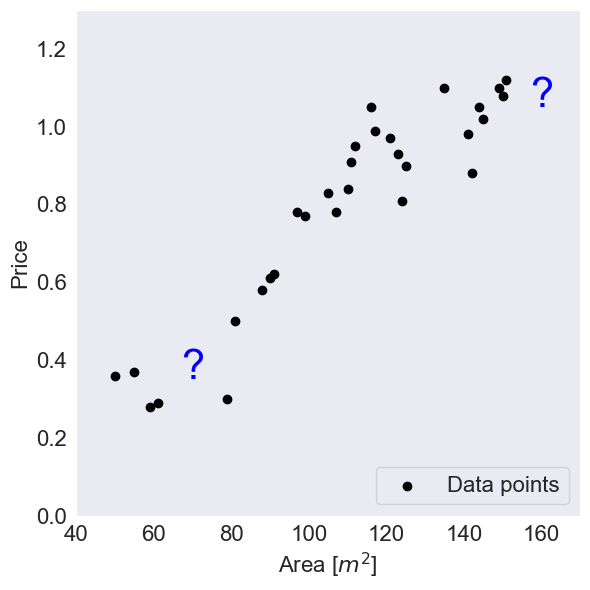

In [22]:
plt.figure()
plt.scatter(x,y, label='Data points', color='k')
plt.ylabel("Price", fontsize=16)
plt.xlabel("Area [$m^2$]", fontsize=16)
plt.xlim((40, 170))
plt.ylim((0, 1.3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.text(70, 0.35, "?", fontsize=30, color='blue', ha='center')
plt.text(160, 1.05, "?", fontsize=30, color='blue', ha='center')
plt.grid()
plt.legend(loc='lower right', fontsize=16)
plt.tight_layout()

In [23]:
# Noise of prior distribution
m = np.zeros((2, 1))
S = np.eye(2)*[0.1,0.1]
sigma2 = 0.3
print(S)

[[0.1 0. ]
 [0.  0.1]]


In [24]:
def mvn_pdf(x, mu, Sigma, log=True):
    """ Returns the density of a multivariate Gaussian distribution
    with mean mu and covariace Sigma at point x

    Arguments:
    x     -- (Dx1) evaluation point
    mu    -- (Dx1) mean vector
    Sigma -- (DxD) covariance matrix
    log   -- (bool) if true, return log density. If false, return the density. (default=True)

    Returns:
    (scalar) density
    """
    D = len(mu)
    Sigma = Sigma + 1e-10 * np.identity(D)
    L = np.linalg.cholesky(Sigma)
    v = np.linalg.solve(L, x-mu)
    const_term = -0.5 * D * np.log(2 * np.pi)
    det_term = -0.5 * 2 * np.sum(np.log(np.diag(L)))
    quad_term = -0.5 * np.sum(v **2)
    if log:
        return const_term + det_term + quad_term
    else:
        return np.exp(const_term + det_term + quad_term)

In [25]:
def predict(x, a, b):
    """ returns prediction for inputs x given parameter (a,b)

    Arguments:
    x    --  (Nx1) vector of inputs
    a    --  slope parameter
    b    --  intercept parameter

    Returns:
    (Nx1) vector of predictions
    """
    return a*x + b


def log_prior(a, b, m, S):
    """ returns the log density of the prior at the points (a,b) given m and S

    Arguments:
    a    -- (scalar) slope parameter
    b    -- (scalar) intercept parameter
    m    -- (2x1) The prior mean
    S    -- (2x2) The prior covariance

    Returns
    (scalar) log density for the pair (a,b)

    """
    return mvn_pdf(np.array([a,b])[:, None], m, S, log=True)

def log_likelihood(x, y, a, b, sigma2):
    """ returns the log-likelihood for the data (x,y) given the parameters (a,b)

    Arguments:
    x    -- (Nx1) vector of inputs
    y    -- (Nx1) vector of responses
    a    -- slope parameter
    b    -- intercept parameter

    Returns:
    (scalar) log likelihood of (x,y)
    """
    log_npdf = lambda x, m, v: -0.5 * np.log(2* np.pi * v) - 0.5 * (x - m)**2/v
    return np.sum(log_npdf(y, predict(x,a,b), sigma2))


def log_posterior(x, y, a, b, m, S, sigma2):
    """Returns the log posterior at (a,b), given the data (x,y) and the prior parameters (m, S).

    Arguments:
    x    -- (Nx1) vector of inputs
    y    -- (Nx1) vector of responses
    a    -- slope parameter
    b    -- intercept parameter
    m    -- (2x1) prior mean of (a, b)
    S    -- (2x2) prior covariance of (a, b)
    sigma2 -- (scalar) noise variance

    Returns:
    (scalar) log posterior at (a, b)
    """
    return log_prior(a, b, m, S) + log_likelihood(x, y, a, b, sigma2)

def log_to_density(Z):
    Z = Z - np.max(Z)
    Z = np.exp(Z)
    return Z/np.sum(Z)

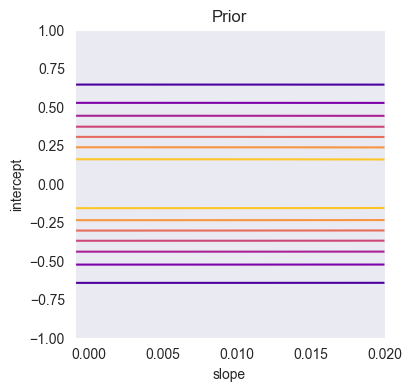

In [26]:
a_array = np.linspace(-0.001,0.02,200)
b_array = np.linspace(-1,1,200)

A_array, B_array = np.meshgrid(a_array, b_array)
Z = np.array([log_prior(ai, bi, m, S) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
Z = Z.reshape((len(a_array), len(b_array)))

plt.figure(figsize=(4,4))
plt.contour(a_array, b_array, log_to_density(Z), cmap='plasma')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.title('Prior')
plt.grid()

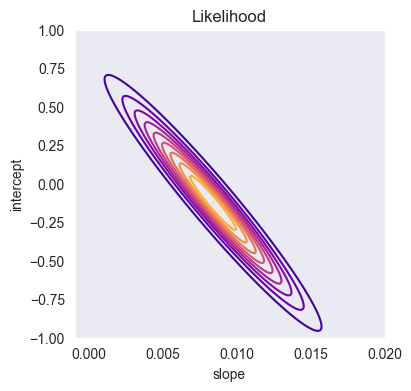

In [27]:
A_array, B_array = np.meshgrid(a_array, b_array)
Z = np.array([log_likelihood(x, y, ai, bi, sigma2) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
Z = Z.reshape((len(a_array), len(b_array)))

plt.figure(figsize=(4,4))
plt.contour(a_array, b_array, log_to_density(Z), 10, cmap='plasma')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.title('Likelihood')
plt.grid()

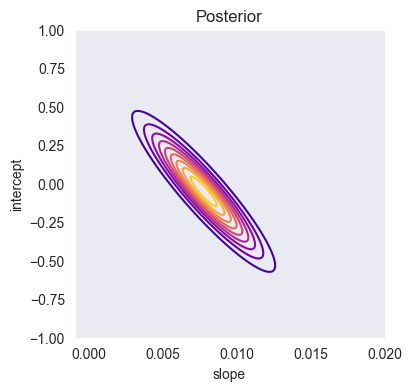

In [28]:
A_array, B_array = np.meshgrid(a_array, b_array)
Z = np.array([log_posterior(x, y, ai, bi, m, S, sigma2) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
Z = Z.reshape((len(a_array), len(b_array)))

plt.figure(figsize=(4,4))
plt.contour(a_array, b_array, log_to_density(Z), 10, cmap='plasma')
plt.xlabel('slope')
plt.ylabel('intercept');
plt.title('Posterior')
plt.grid()

In [29]:
def design_matrix(x):
    """ returns the design matrix for a vector of input values x

    Arguments:
    x    -- (Nx1) vector of inputs

    Returns:
    (Nx2) design matrix

    """
    X = np.column_stack((x, np.ones(len(x))))
    return X

def compute_posterior(x, y, m, S, sigma2):
    """ return the posterior mean and covariance of w given (x,y)
    and hyperparameters m, S and sigma2

    Arguments:
    x      -- (Nx1) vector of inputs
    y      -- (Nx1) vector of responses
    m      -- (Dx1) prior mean
    S      -- (DxD) prior covariance
    sigma2 -- (scalar) noise variance

    Returns:
    mu     -- (Dx1) posterior mean
    Sigma  -- (DxD) posterior covariance

    """
    import scipy as sc
    Sinv = np.linalg.inv(S)
    X = design_matrix(x)
    Sigmainv = Sinv + np.dot(X.T, X)/sigma2
    L = sc.linalg.cho_factor(Sigmainv)
    scaled_mu = np.dot(X.T, y)/sigma2 + np.linalg.solve(S,m)
    mu = sc.linalg.cho_solve(L, scaled_mu)
    Sigma = sc.linalg.cho_solve(L, np.identity(len(m)))

    return mu, Sigma

mu, Sigma = compute_posterior(x[:,None], y[:, None], m, S, sigma2)

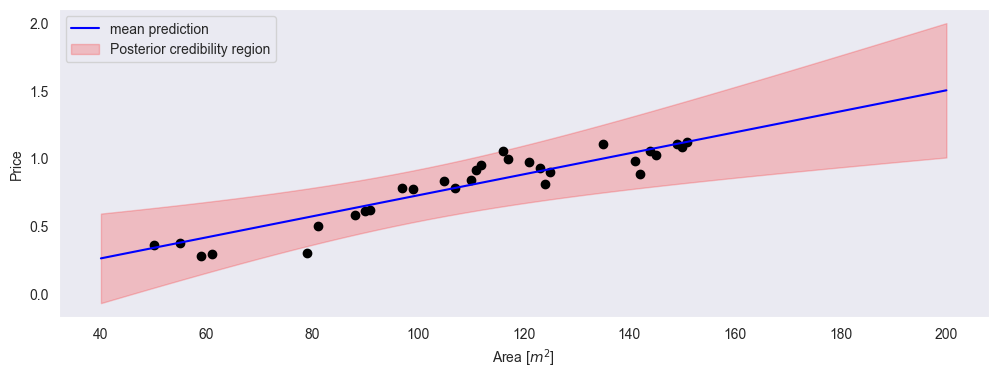

In [30]:
def compute_f_posterior(x, mu, Sigma):
    """ compute the posterior distribution of f(x) wrt. posterior distribution N(mu, Sigma)

    Arguments:
    x      -- (Nx1) vector of inputs
    mu     -- (2x1) mean vector
    Sigma  -- (2x2) covariance matrix

    Returns:
    mu_f   -- (Nx1) vector of pointwise posterior means at x
    var_f  -- (Nx1) vector of pointwise posterior variances at x

    """

    X = np.column_stack((x, np.ones(len(x))))
    mu_f = np.dot(X, mu)
    var_f = np.diag(np.dot(np.dot(X, Sigma), X.T))[:, None]

    return mu_f, var_f

xp = np.linspace(40, 200, 50)
mu_f, var_f = compute_f_posterior(xp, mu, Sigma)
std_f = np.sqrt(var_f)
mu_f = mu_f.reshape(-1)
std_f = std_f.reshape(-1)

plt.figure(figsize=(12,4))
plt.plot(x, y, 'k.', markersize=12);
plt.plot(xp, mu_f, 'b', label='mean prediction')
plt.fill_between(xp, mu_f - 2*std_f, mu_f + 2*std_f, alpha=0.2, color='r', label='Posterior credibility region')
plt.xlabel('Area [$m^2$]')
plt.ylabel('Price')
plt.legend()
plt.grid()

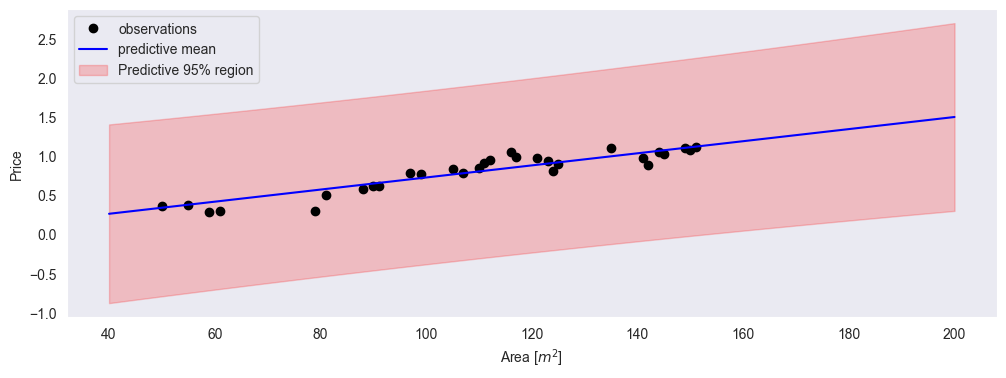

In [31]:
var_y = var_f + sigma2

std_y = np.sqrt(var_y)
mu_f = mu_f.reshape(-1)
std_y = std_y.reshape(-1)

plt.figure(figsize=(12, 4))
plt.plot(x, y, 'k.', markersize=12, label='observations')
plt.plot(xp, mu_f, 'b', label='predictive mean')
plt.fill_between(
    xp,
    mu_f - 2 * std_y,
    mu_f + 2 * std_y,
    alpha=0.2,
    color='r',
    label='Predictive 95% region'
)
plt.xlabel('Area [$m^2$]')
plt.ylabel('Price')
plt.legend()
plt.grid()